# Computer Vision Architectures - CNN & ViT
---

## Abstract 
On this project I tried to implement from scratch 2 types of computer vision classifier architectures : Convolutional Neural Networks & Vision Transformer. 
I trained and tested the models on the CIFAR-10 dataset. 
i was able to achive


## Convolutional Neural Networks 


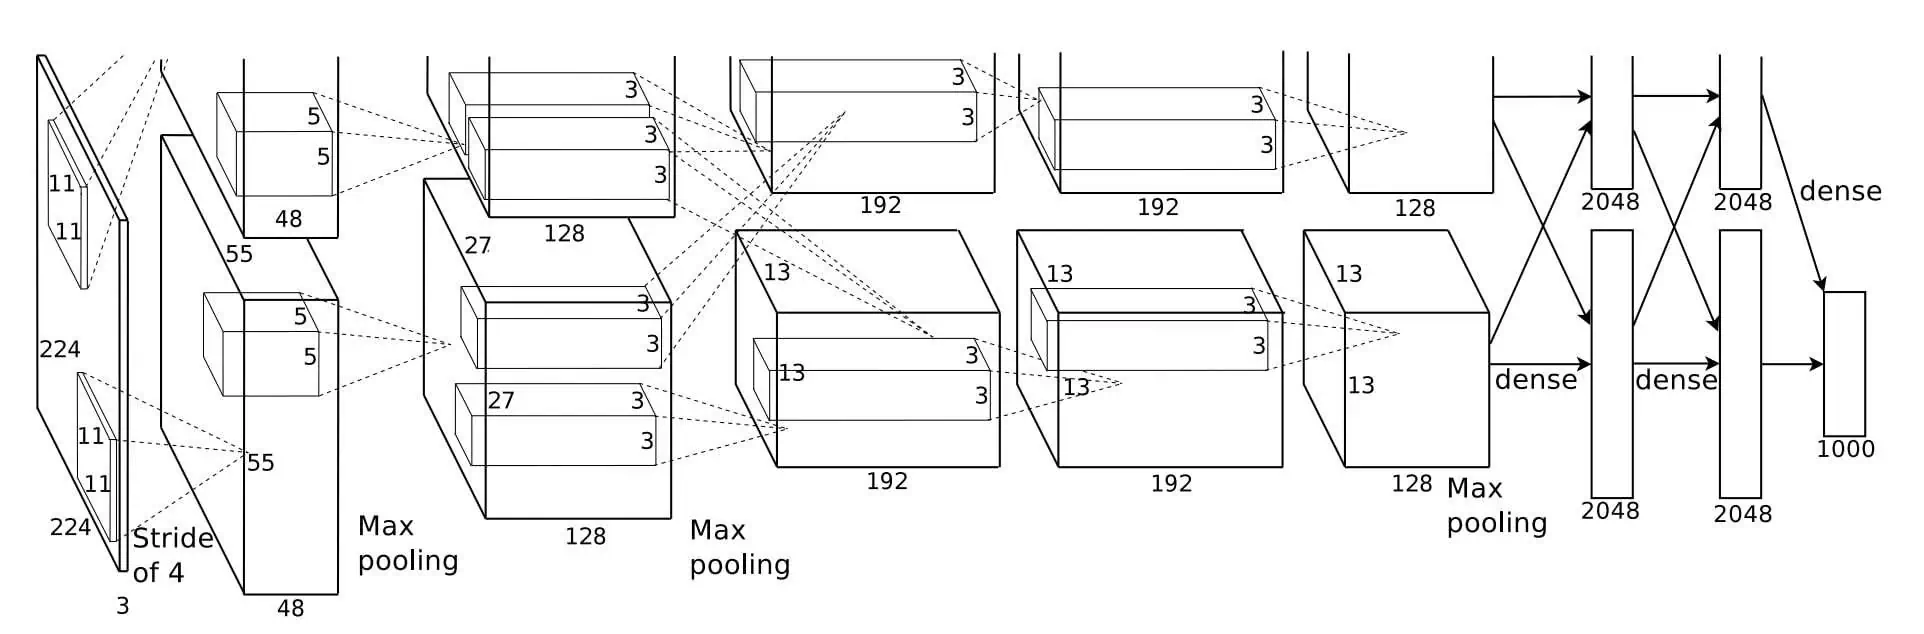

Dans notre projet, on construit 5 CNN : CNN1, CNN2, CNN3, CNN4, dont voici les résultats finaux : 

In [17]:
import torch
import sys
sys.path.insert(0, '..')
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from src.cnn.models import mycnn, LeNet, CNN1, CNN2, CNN3, CNN4

MODEL_DICT = {
    'mycnn_v1': mycnn,
    'lenet': LeNet,
    'cnn1': CNN1,
    'cnn2': CNN2,
    'cnn3': CNN3,
    'cnn4': CNN4
}

def cnn_test(model_name):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    test_data = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)
    test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

    model = MODEL_DICT[model_name]().to(device)

    state_dict = torch.load(f'../data/models/{model_name}.pth', map_location=device)
    model.load_state_dict(state_dict)

    model.eval()


    correct = 0
    total = 0  
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()   
    print(f"Précision du modèle {model_name} sur le jeu de test : {100 * correct / total:.2f}%")

for model_name in MODEL_DICT.keys():
    cnn_test(model_name)


Précision du modèle mycnn_v1 sur le jeu de test : 78.27%
Précision du modèle lenet sur le jeu de test : 69.05%
Précision du modèle cnn1 sur le jeu de test : 62.21%
Précision du modèle cnn2 sur le jeu de test : 50.86%
Précision du modèle cnn3 sur le jeu de test : 52.90%
Précision du modèle cnn4 sur le jeu de test : 53.08%
